> **Repository note.** Paper Experiment A: controlled sense-diagnostic evidence versus matched random context.
> This notebook is preserved with executed outputs from the research run. Large embedding caches and third-party datasets are intentionally not bundled. See `REPRODUCIBILITY.md` at the repository root.


# Semantic Disambiguation Geometry — V3 Resource Run

## Goal

V2 produced a valid pilot signal consistent with a **separation-first** picture:

\[
\text{informative context}
\Rightarrow
\text{sense decodability}\uparrow,\qquad
D_{\text{between}}\uparrow
\]

while early:

\[
\Delta V_{\text{within}}\approx 0,
\]

and only later:

\[
\Delta V_{\text{within}}<0
\]

relative to equally rich random context.

V3 is not another pilot. It is designed to create a **large reusable result resource** with:

- all 20 CoarseWSD-20 ambiguous nouns where data permit;
- 3 encoder families;
- 5 random-context seeds;
- layers 4/8/12;
- 5 evidence levels;
- matched-count controls;
- mask-artifact ablation;
- local-context and anti-PMI controls;
- bootstrap confidence intervals over lexical items;
- random-seed stability;
- per-word mechanism profiles;
- cached embeddings and restart-safe intermediate outputs.

The core scientific question remains simple:

\[
\boxed{
\text{When context resolves lexical ambiguity, does geometry contract, separate, or enrich?}
}
\]

## Experiment matrix

### Main cross-model experiment

Models:

- `bert-base-uncased`
- `roberta-base`
- `microsoft/deberta-v3-base`

For every model:

- all eligible CoarseWSD-20 words;
- layers \(4,8,12\);
- \(k\in\{1,2,4,8,16\}\) visible context tokens;
- `gold_pmi` informative evidence;
- **5 independent random reveal orderings**.

This directly estimates:

\[
\Delta W_k
=
W_{\text{gold-PMI},k}
-
\mathbb E_r W_{\text{random-}r,k}
\]

and

\[
\Delta B_k
=
B_{\text{gold-PMI},k}
-
\mathbb E_r B_{\text{random-}r,k}.
\]

### BERT-only strategy ablation

Also test:

- `local`: nearest tokens first;
- `anti_pmi`: least gold-sense-diagnostic tokens first.

This asks whether the result follows a graded evidence ordering:

\[
\text{gold-PMI} > \text{local/random} > \text{anti-PMI}.
\]

### BERT-only masking ablation

Repeat the main gold-vs-random experiment with hidden tokens **deleted** instead of replaced by `[MASK]`.

This tests whether the result is a mask-token artifact.

### Why not add a second WSD dataset yet?

CoarseWSD-20 already gives the full 20-word controlled lexical panel.  
A second dataset is better treated as external replication after this resource run, because sense inventories and target-index conventions differ and would complicate interpretation before the main effect is fully characterized.

In [1]:
# Kaggle / Colab setup
!pip -q install "datasets>=2.18,<4" "transformers>=4.43,<5" accelerate scipy scikit-learn pandas pyarrow tqdm sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.


In [2]:
import gc
import math
import json
import random
import hashlib
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset

from sklearn.metrics import balanced_accuracy_score, f1_score
from sklearn.decomposition import PCA

from scipy.spatial.distance import pdist
from scipy.stats import wilcoxon, spearmanr

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("device:", DEVICE)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

device: cuda
gpu: Tesla T4


## Resource-run configuration

The default is intentionally substantial but still structured to fit a long Kaggle GPU session.

If interrupted, rerun the notebook: completed model/protocol embedding caches are reused.

In [3]:
PROFILE = "resource"  # "smoke" or "resource"

DATASET_ID = "kiamehr74/CoarseWSD-20"

ALL_WORDS = [
    "apple", "arm", "bank", "bass", "bow",
    "chair", "club", "crane", "deck", "digit",
    "hood", "java", "mole", "pitcher", "pound",
    "seal", "spring", "square", "trunk", "yard",
]

MAIN_MODELS = [
    "bert-base-uncased",
    "roberta-base",
    "microsoft/deberta-v3-base",
]

MAIN_LAYERS = [4, 8, 12]
MAIN_LAYER = 12
REVEAL_COUNTS = [1, 2, 4, 8, 16]

if PROFILE == "smoke":
    WORDS = ["bank", "bass", "java", "spring"]
    RANDOM_SEEDS = [11, 29]
    MAX_TRAIN_PER_SENSE = 80
    MAX_TEST_PER_SENSE = 50
    MODELS = ["bert-base-uncased"]
    RUN_DELETE_ABLATION = False
    RUN_STRATEGY_ABLATION = True
else:
    WORDS = ALL_WORDS
    RANDOM_SEEDS = [11, 29, 47, 83, 131]
    MAX_TRAIN_PER_SENSE = 120
    MAX_TEST_PER_SENSE = 80
    MODELS = MAIN_MODELS
    RUN_DELETE_ABLATION = True
    RUN_STRATEGY_ABLATION = True

MIN_TRAIN_PER_SENSE = 15
MIN_TEST_PER_SENSE = 8

MAX_WORDS = 96
ENCODE_BATCH_SIZE = 96

BOOTSTRAP_ITERS = 10000

ROOT = Path("semantic_disambiguation_geometry_v3")
CACHE_DIR = ROOT / "cache"
RESULT_DIR = ROOT / "results"
PLOT_DIR = ROOT / "plots"

for p in [CACHE_DIR, RESULT_DIR, PLOT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("profile:", PROFILE)
print("words:", len(WORDS))
print("models:", MODELS)
print("random seeds:", RANDOM_SEEDS)

profile: resource
words: 20
models: ['bert-base-uncased', 'roberta-base', 'microsoft/deberta-v3-base']
random seeds: [11, 29, 47, 83, 131]


## 1. Load and validate CoarseWSD-20

Sampling is balanced **inside each word**:

\[
n_w
=
\min\left(
\text{cap},
\min_s n_{w,s}
\right).
\]

Every retained sense of word \(w\) contributes exactly \(n_w\) examples.

This prevents label-ID collisions and unstable sense centroids.

In [4]:
def crop_around_target(tokens, target_idx, max_words=96):
    if len(tokens) <= max_words:
        return tokens, target_idx

    half = max_words // 2
    left = max(0, target_idx - half)
    right = min(len(tokens), left + max_words)
    left = max(0, right - max_words)

    return tokens[left:right], target_idx - left


def load_word_config(word):
    ds = load_dataset(DATASET_ID, word, trust_remote_code=True)
    label_names = ds["train"].features["label"].names

    frames = []

    for split in ["train", "test"]:
        d = ds[split].to_pandas()
        d["word"] = word
        d["split"] = split
        d["sense_name"] = d["label"].map(dict(enumerate(label_names)))

        token_lists = []
        target_indices = []
        target_ok = []

        for _, row in d.iterrows():
            toks = str(row["sentence"]).split()
            idx = int(row["idx"])

            if not (0 <= idx < len(toks)):
                token_lists.append([])
                target_indices.append(-1)
                target_ok.append(False)
                continue

            toks, idx = crop_around_target(toks, idx, MAX_WORDS)
            surface = toks[idx].lower().strip('.,;:!?()[]{}"')

            token_lists.append(toks)
            target_indices.append(idx)
            target_ok.append(
                word.lower() in surface or surface in word.lower()
            )

        d["tokens"] = token_lists
        d["target_idx"] = target_indices
        d["target_check"] = target_ok
        d["example_id"] = [
            f"{word}:{split}:{i}" for i in range(len(d))
        ]
        frames.append(d)

    return pd.concat(frames, ignore_index=True)


all_df = pd.concat(
    [
        load_word_config(w)
        for w in tqdm(WORDS, desc="loading CoarseWSD-20")
    ],
    ignore_index=True,
)

if not all_df["target_check"].all():
    bad = all_df[~all_df["target_check"]]
    display(bad[["word", "sentence", "idx", "target_idx"]].head())
    raise RuntimeError("Target index sanity check failed.")

raw_counts = (
    all_df
    .groupby(["word", "split", "sense_name"])
    .size()
    .rename("n")
    .reset_index()
)

display(raw_counts)

loading CoarseWSD-20:   0%|          | 0/20 [00:00<?, ?it/s]

CoarseWSD-20.py: 0.00B [00:00, ?B/s]

0000.parquet:   0%|          | 0.00/279k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/124k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2358 [00:00<?, ? examples/s]

...

0000.parquet:   0%|          | 0.00/20.0k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/12.4k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/144 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/72 [00:00<?, ? examples/s]

,word,split,sense_name,n
0,apple,test,apple_apple,398
1,apple,test,apple_apple_inc.,634
2,apple,train,apple_apple,892
3,apple,train,apple_apple_inc.,1466
4,arm,test,arm_arm,43
...,...,...,...,...
101,trunk,train,trunk_trunk_(botany),93
102,yard,test,yard_yard,61
103,yard,test,yard_yard_(sailing),11
104,yard,train,yard_yard,121


In [5]:
def balanced_sample_per_word(
    df,
    cap_per_sense,
    min_per_sense,
    seed=SEED,
):
    parts = []
    kept = []
    dropped = []

    for word, gw in df.groupby("word", sort=True):
        counts = gw.groupby("label").size()
        n = min(int(counts.min()), int(cap_per_sense))

        if n < min_per_sense:
            dropped.append({
                "word": word,
                "min_available": int(counts.min()),
                "required": int(min_per_sense),
            })
            continue

        for label, gs in gw.groupby("label", sort=True):
            sample_seed = int(
                hashlib.md5(
                    f"{seed}|{word}|{int(label)}".encode()
                ).hexdigest()[:8],
                16,
            )
            parts.append(gs.sample(n=n, random_state=sample_seed))

        kept.append({
            "word": word,
            "n_senses": len(counts),
            "n_per_sense": n,
            "total": n * len(counts),
        })

    if not parts:
        raise RuntimeError("No words satisfy the minimum count threshold.")

    return (
        pd.concat(parts, ignore_index=True),
        pd.DataFrame(kept),
        pd.DataFrame(dropped),
    )


train_all = all_df[all_df["split"] == "train"].copy()
test_all = all_df[all_df["split"] == "test"].copy()

train_df, train_sampling, train_dropped = balanced_sample_per_word(
    train_all,
    MAX_TRAIN_PER_SENSE,
    MIN_TRAIN_PER_SENSE,
)

test_df, test_sampling, test_dropped = balanced_sample_per_word(
    test_all,
    MAX_TEST_PER_SENSE,
    MIN_TEST_PER_SENSE,
)

VALID_WORDS = sorted(
    set(train_df["word"]) & set(test_df["word"])
)

train_df = train_df[train_df["word"].isin(VALID_WORDS)].reset_index(drop=True)
test_df = test_df[test_df["word"].isin(VALID_WORDS)].reset_index(drop=True)

print("eligible words:", len(VALID_WORDS), VALID_WORDS)
print("train examples:", len(train_df))
print("test examples :", len(test_df))

display(train_sampling[train_sampling["word"].isin(VALID_WORDS)])
display(test_sampling[test_sampling["word"].isin(VALID_WORDS)])

if len(train_dropped):
    print("Dropped from train:")
    display(train_dropped)

if len(test_dropped):
    print("Dropped from test:")
    display(test_dropped)

# Hard verification of balanced word x sense sampling.
check = (
    test_df
    .groupby(["word", "label"])
    .size()
    .rename("n")
    .reset_index()
)

assert all(
    g["n"].nunique() == 1
    for _, g in check.groupby("word")
)

display(check)

eligible words: 19 ['apple', 'arm', 'bank', 'bass', 'bow', 'chair', 'club', 'crane', 'digit', 'hood', 'java', 'mole', 'pitcher', 'pound', 'seal', 'spring', 'square', 'trunk', 'yard']
train examples: 3208
test examples : 1653


,word,n_senses,n_per_sense,total
0,apple,2,120,240
1,arm,2,112,224
2,bank,2,46,92
3,bass,3,120,360
4,bow,3,72,216
5,chair,2,115,230
6,club,3,54,162
7,crane,2,120,240
9,digit,2,21,42
10,hood,3,24,72


,word,n_senses,n_per_sense,total
0,apple,2,80,160
1,arm,2,43,86
2,bank,2,22,44
3,bass,3,80,240
4,bow,3,26,78
5,chair,2,42,84
6,club,3,21,63
7,crane,2,76,152
8,digit,2,9,18
9,hood,3,13,39


Dropped from test:


,word,min_available,required
0,deck,7,8


,word,label,n
0,apple,0,80
1,apple,1,80
2,arm,0,43
3,arm,1,43
4,bank,0,22
5,bank,1,22
6,bass,0,80
7,bass,1,80
8,bass,2,80
9,bow,0,26


## 2. Sense-diagnostic evidence table

Gold-sense PMI is estimated using **all official training examples** for eligible words, not the balanced analysis subsample.

\[
\operatorname{PMI}(t,s)
=
\log \frac{P(t\mid s)}{P(t)}.
\]

A token must appear in at least two training contexts to enter the PMI table.

The gold label is used only to construct the controlled intervention.

In [6]:
PUNCT = set(".,;:!?()[]{}\"'`-–—")


def norm_token(t):
    return t.lower().strip(".,;:!?()[]{}\"'`")


def is_punctuation_token(t):
    s = t.strip()
    return len(s) > 0 and all(ch in PUNCT for ch in s)


def build_pmi_tables(df, alpha=0.5, min_total_df=2):
    tables = {}

    for word, g in df.groupby("word"):
        n_all = len(g)
        labels = sorted(g["label"].astype(int).unique())

        all_dfreq = Counter()
        sense_dfreq = {int(l): Counter() for l in labels}
        n_sense = Counter(g["label"].astype(int))

        for _, row in g.iterrows():
            seen = set()
            target_idx = int(row["target_idx"])

            for i, tok in enumerate(row["tokens"]):
                if i == target_idx:
                    continue

                nt = norm_token(tok)
                if not nt or is_punctuation_token(tok):
                    continue
                if nt == word.lower():
                    continue

                seen.add(nt)

            all_dfreq.update(seen)
            sense_dfreq[int(row["label"])].update(seen)

        vocab = {
            tok
            for tok, c in all_dfreq.items()
            if c >= min_total_df
        }

        word_table = {}

        for lab in labels:
            lab = int(lab)
            scores = {}

            for tok in vocab:
                p_ts = (
                    sense_dfreq[lab][tok] + alpha
                ) / (
                    n_sense[lab] + 2 * alpha
                )

                p_t = (
                    all_dfreq[tok] + alpha
                ) / (
                    n_all + 2 * alpha
                )

                scores[tok] = math.log(p_ts / p_t)

            word_table[lab] = scores

        tables[word] = word_table

    return tables


PMI_TABLES = build_pmi_tables(
    train_all[train_all["word"].isin(VALID_WORDS)]
)

print("PMI tables:", len(PMI_TABLES))

PMI tables: 19


## 3. Context-selection strategies

Cross-model main experiment:

- `gold_pmi`
- `random_s11`
- `random_s29`
- `random_s47`
- `random_s83`
- `random_s131`

BERT strategy ablation additionally uses:

- `local`
- `anti_pmi`

For `anti_pmi`, context positions are ordered from **least** diagnostic of the gold sense to most diagnostic.

In [7]:
def context_positions(tokens, target_idx):
    return [
        i
        for i, tok in enumerate(tokens)
        if i != target_idx and not is_punctuation_token(tok)
    ]


def strategy_names(random_seeds, include_extra=False):
    names = ["gold_pmi"]
    names += [f"random_s{s}" for s in random_seeds]

    if include_extra:
        names += ["local", "anti_pmi"]

    return names


MAIN_STRATEGIES = strategy_names(RANDOM_SEEDS, include_extra=False)
BERT_EXTRA_STRATEGIES = ["local", "anti_pmi"]


def rank_positions(row, strategy):
    tokens = row["tokens"]
    target_idx = int(row["target_idx"])
    positions = context_positions(tokens, target_idx)

    if strategy == "local":
        return sorted(
            positions,
            key=lambda i: (abs(i - target_idx), i),
        )

    if strategy.startswith("random_s"):
        rseed = int(strategy.split("random_s", 1)[1])

        seed = int(
            hashlib.md5(
                f"{rseed}|{row['example_id']}".encode()
            ).hexdigest()[:8],
            16,
        )

        rng = random.Random(seed)
        positions = positions.copy()
        rng.shuffle(positions)
        return positions

    scores = PMI_TABLES[row["word"]][int(row["label"])]

    if strategy == "gold_pmi":
        return sorted(
            positions,
            key=lambda i: scores.get(norm_token(tokens[i]), -999.0),
            reverse=True,
        )

    if strategy == "anti_pmi":
        return sorted(
            positions,
            key=lambda i: scores.get(norm_token(tokens[i]), -999.0),
        )

    raise ValueError(strategy)


def visible_evidence_score(row, ranked_positions, k):
    scores = PMI_TABLES[row["word"]][int(row["label"])]
    chosen = ranked_positions[:k]

    vals = [
        scores.get(norm_token(row["tokens"][i]), np.nan)
        for i in chosen
    ]
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return np.nan

    return float(vals.mean())

## 4. Two context protocols

### `mask`

All hidden non-punctuation tokens become the model's mask token.

Advantages:

- same sentence length;
- same target position;
- exactly matched visible-token count.

### `delete`

Hidden context tokens are removed.

Advantages:

- no mask-token artifact.

Disadvantage:

- target position and sequence length change.

The expensive delete ablation is run only for BERT by default.

In [8]:
def make_variant(
    row,
    strategy,
    reveal_k,
    protocol,
    mask_token=None,
):
    tokens = list(row["tokens"])
    target_idx = int(row["target_idx"])

    ranked = rank_positions(row, strategy)
    visible = set(ranked[:reveal_k])

    evidence_score = visible_evidence_score(
        row,
        ranked,
        reveal_k,
    )

    if protocol == "mask":
        if mask_token is None:
            raise ValueError("mask_token required for mask protocol")

        out = []

        for i, tok in enumerate(tokens):
            if i == target_idx:
                out.append(tok)
            elif is_punctuation_token(tok):
                out.append(tok)
            elif i in visible:
                out.append(tok)
            else:
                out.append(mask_token)

        return out, target_idx, evidence_score

    if protocol == "delete":
        out = []
        new_target = None

        for i, tok in enumerate(tokens):
            keep = (
                i == target_idx
                or is_punctuation_token(tok)
                or i in visible
            )

            if keep:
                if i == target_idx:
                    new_target = len(out)
                out.append(tok)

        if new_target is None:
            raise RuntimeError("target disappeared")

        return out, new_target, evidence_score

    raise ValueError(protocol)


def build_variants(
    df,
    strategies,
    protocol,
    mask_token,
):
    records = []

    keep_cols = [
        "example_id",
        "word",
        "label",
        "sense_name",
    ]

    for _, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc=f"variants:{protocol}",
    ):
        base = row.to_dict()

        for strategy in strategies:
            for k in REVEAL_COUNTS:
                toks, target_idx, evidence = make_variant(
                    row,
                    strategy,
                    k,
                    protocol,
                    mask_token=mask_token,
                )

                rec = {
                    c: base[c]
                    for c in keep_cols
                }

                rec.update({
                    "strategy": strategy,
                    "reveal_k": int(k),
                    "protocol": protocol,
                    "tokens_variant": toks,
                    "target_idx_variant": int(target_idx),
                    "mean_gold_pmi_visible": evidence,
                })

                records.append(rec)

    return pd.DataFrame(records)

## 5. Encoder helpers and restart-safe cache

Each model is loaded separately and deleted after metrics are written.

Cached items:

- variant metadata;
- layer 4/8/12 target embeddings;
- condition-level metrics.

This prevents a late notebook interruption from wasting earlier model runs.

In [9]:
def safe_model_name(name):
    return name.replace("/", "__")


def load_encoder(model_name):
    kwargs = {"use_fast": True}

    if "roberta" in model_name.lower():
        kwargs["add_prefix_space"] = True

    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        **kwargs,
    )

    model = AutoModel.from_pretrained(
        model_name,
        output_hidden_states=True,
    )

    model.to(DEVICE)
    model.eval()

    if tokenizer.mask_token is None:
        raise RuntimeError(
            f"{model_name} has no mask token; mask protocol unavailable."
        )

    return tokenizer, model


@torch.inference_mode()
def encode_target_tokens(
    model,
    tokenizer,
    token_lists,
    target_indices,
    layers=MAIN_LAYERS,
    batch_size=ENCODE_BATCH_SIZE,
):
    outputs = {layer: [] for layer in layers}

    for start in tqdm(
        range(0, len(token_lists), batch_size),
        desc="encoding",
    ):
        btok = token_lists[start:start + batch_size]
        bidx = target_indices[start:start + batch_size]

        enc = tokenizer(
            btok,
            is_split_into_words=True,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt",
        )

        word_ids = [
            enc.word_ids(batch_index=i)
            for i in range(len(btok))
        ]

        gpu = {
            k: v.to(DEVICE)
            for k, v in enc.items()
        }

        out = model(**gpu)

        for layer in layers:
            h = out.hidden_states[layer]
            vecs = []

            for b, target_idx in enumerate(bidx):
                positions = [
                    j
                    for j, wid in enumerate(word_ids[b])
                    if wid == int(target_idx)
                ]

                if not positions:
                    raise RuntimeError(
                        "Target token lost after tokenization/truncation."
                    )

                vecs.append(
                    h[b, positions, :].mean(dim=0)
                )

            outputs[layer].append(
                torch.stack(vecs)
                .float()
                .cpu()
                .numpy()
            )

    return {
        layer: np.concatenate(chunks, axis=0)
        for layer, chunks in outputs.items()
    }


def l2_normalize_rows(x, eps=1e-12):
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(norms, eps)

## 6. Stage-matched decodability and geometric metrics

For each exact condition:

\[
(\text{model},\text{layer},\text{protocol},\text{strategy},k,\text{word})
\]

training variants form sense centroids.

Test metrics:

- balanced WSD accuracy;
- macro-F1;
- gold-vs-best-other cosine margin;
- within-sense dispersion \(W\);
- between-sense separation \(B\);
- \(B/W\);
- effective rank.

No full-context calibration is transferred to masked conditions.

In [10]:
def mean_pairwise_cosine_distance(x):
    if len(x) < 2:
        return np.nan

    return float(np.mean(pdist(x, metric="cosine")))


def effective_rank_centered(x, eps=1e-12):
    if len(x) < 3:
        return np.nan

    xc = x - x.mean(axis=0, keepdims=True)
    s = np.linalg.svd(
        xc,
        compute_uv=False,
        full_matrices=False,
    )

    energy = s ** 2

    if energy.sum() <= eps:
        return 1.0

    p = energy / energy.sum()
    p = p[p > eps]

    return float(np.exp(-(p * np.log(p)).sum()))


def cloud_metrics(x, labels):
    labels = np.asarray(labels)
    senses = sorted(np.unique(labels))

    within = []
    centroids = []

    for s in senses:
        xs = x[labels == s]

        within.append(
            mean_pairwise_cosine_distance(xs)
        )

        c = xs.mean(axis=0)
        c = c / max(np.linalg.norm(c), 1e-12)
        centroids.append(c)

    centroids = np.stack(centroids)

    between = float(
        np.mean(pdist(centroids, metric="cosine"))
    )

    within_macro = float(np.nanmean(within))

    return {
        "within_dispersion": within_macro,
        "between_separation": between,
        "separation_ratio": (
            between / max(within_macro, 1e-12)
        ),
        "effective_rank": effective_rank_centered(x),
    }


def compute_condition_metrics(
    train_meta,
    test_meta,
    train_emb,
    test_emb,
):
    records = []

    group_cols = [
        "word",
        "strategy",
        "reveal_k",
        "protocol",
    ]

    for key, gtest in test_meta.groupby(group_cols, sort=False):
        word, strategy, reveal_k, protocol = key

        gtrain = train_meta[
            (train_meta["word"] == word)
            & (train_meta["strategy"] == strategy)
            & (train_meta["reveal_k"] == reveal_k)
            & (train_meta["protocol"] == protocol)
        ]

        labels = sorted(gtrain["label"].astype(int).unique())

        centroids = []

        for lab in labels:
            idx = gtrain.index[
                gtrain["label"].astype(int) == lab
            ].to_numpy()

            c = train_emb[idx].mean(axis=0)
            c = c / max(np.linalg.norm(c), 1e-12)
            centroids.append(c)

        centroids = np.stack(centroids)

        test_idx = gtest.index.to_numpy()
        x = test_emb[test_idx]
        gold = gtest["label"].astype(int).to_numpy()

        sims = x @ centroids.T
        pred_col = sims.argmax(axis=1)
        pred = np.array([labels[j] for j in pred_col])

        label_to_col = {
            lab: j for j, lab in enumerate(labels)
        }
        gold_col = np.array([label_to_col[y] for y in gold])

        gold_sim = sims[np.arange(len(sims)), gold_col]

        others = sims.copy()
        others[np.arange(len(sims)), gold_col] = -np.inf
        margin = gold_sim - others.max(axis=1)

        geom = cloud_metrics(x, gold)

        records.append({
            "word": word,
            "strategy": strategy,
            "reveal_k": int(reveal_k),
            "protocol": protocol,
            "balanced_accuracy": balanced_accuracy_score(gold, pred),
            "macro_f1": f1_score(gold, pred, average="macro"),
            "mean_gold_margin": float(margin.mean()),
            "mean_gold_pmi_visible": float(
                gtest["mean_gold_pmi_visible"].mean()
            ),
            "n_test": len(gtest),
            **geom,
        })

    return pd.DataFrame(records)

## 7. One cached experiment runner

In [11]:
def run_condition_set(
    model_name,
    protocol,
    strategies,
    tag,
):
    model_key = safe_model_name(model_name)
    exp_dir = CACHE_DIR / f"{model_key}__{protocol}__{tag}"
    exp_dir.mkdir(parents=True, exist_ok=True)

    metrics_path = exp_dir / "metrics.csv"

    if metrics_path.exists():
        print("CACHE HIT:", metrics_path)
        return pd.read_csv(metrics_path)

    tokenizer, model = load_encoder(model_name)

    train_meta_path = exp_dir / "train_variants.parquet"
    test_meta_path = exp_dir / "test_variants.parquet"

    if train_meta_path.exists() and test_meta_path.exists():
        train_meta = pd.read_parquet(train_meta_path)
        test_meta = pd.read_parquet(test_meta_path)
    else:
        train_meta = build_variants(
            train_df,
            strategies,
            protocol,
            tokenizer.mask_token,
        )
        test_meta = build_variants(
            test_df,
            strategies,
            protocol,
            tokenizer.mask_token,
        )

        train_meta.to_parquet(train_meta_path, index=False)
        test_meta.to_parquet(test_meta_path, index=False)

    train_emb = encode_target_tokens(
        model,
        tokenizer,
        train_meta["tokens_variant"].tolist(),
        train_meta["target_idx_variant"].astype(int).tolist(),
    )

    test_emb = encode_target_tokens(
        model,
        tokenizer,
        test_meta["tokens_variant"].tolist(),
        test_meta["target_idx_variant"].astype(int).tolist(),
    )

    metrics_frames = []

    for layer in MAIN_LAYERS:
        tr = l2_normalize_rows(train_emb[layer])
        te = l2_normalize_rows(test_emb[layer])

        # Save embeddings to permit later analyses without re-encoding.
        np.save(exp_dir / f"train_layer{layer}.npy", tr.astype(np.float32))
        np.save(exp_dir / f"test_layer{layer}.npy", te.astype(np.float32))

        m = compute_condition_metrics(
            train_meta,
            test_meta,
            tr,
            te,
        )

        m["model"] = model_name
        m["layer"] = layer
        m["tag"] = tag

        metrics_frames.append(m)

    metrics = pd.concat(metrics_frames, ignore_index=True)
    metrics.to_csv(metrics_path, index=False)

    del train_emb, test_emb, model, tokenizer
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics

## 8. Main cross-model run

This is the largest block.

It runs:

\[
3	ext{ models}
	imes
3	ext{ layers}
	imes
5	ext{ reveal counts}
	imes
(1+5)	ext{ strategies}
	imes
	ext{all eligible words}.
\]

Embedding caches make it restart-safe.

In [12]:
main_metric_frames = []

for model_name in MODELS:
    print("\n" + "=" * 80)
    print("MAIN MODEL:", model_name)
    print("=" * 80)

    m = run_condition_set(
        model_name=model_name,
        protocol="mask",
        strategies=MAIN_STRATEGIES,
        tag="main",
    )

    main_metric_frames.append(m)

main_metrics = pd.concat(main_metric_frames, ignore_index=True)

main_metrics.to_csv(
    RESULT_DIR / "main_cross_model_condition_metrics.csv",
    index=False,
)

display(main_metrics.head())


MAIN MODEL: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

variants:mask:   0%|          | 0/3208 [00:00<?, ?it/s]

variants:mask:   0%|          | 0/1653 [00:00<?, ?it/s]

encoding:   0%|          | 0/1003 [00:00<?, ?it/s]

encoding:   0%|          | 0/517 [00:00<?, ?it/s]

,word,strategy,reveal_k,protocol,balanced_accuracy,macro_f1,mean_gold_margin,mean_gold_pmi_visible,n_test,within_dispersion,between_separation,separation_ratio,effective_rank,model,layer,tag
0,apple,gold_pmi,1,mask,0.90000,0.899434,0.053618,0.712614,160,0.142978,0.072274,0.505487,23.651489,bert-base-uncased,4,main
1,apple,gold_pmi,2,mask,0.97500,0.974984,0.115593,0.692614,160,0.162163,0.147410,0.909025,22.254036,bert-base-uncased,4,main
2,apple,gold_pmi,4,mask,0.98750,0.987500,0.196380,0.646480,160,0.182630,0.231955,1.270083,20.962870,bert-base-uncased,4,main
3,apple,gold_pmi,8,mask,1.00000,1.000000,0.249618,0.539657,160,0.200471,0.286983,1.431546,21.464657,bert-base-uncased,4,main
4,apple,gold_pmi,16,mask,0.99375,0.993750,0.252368,0.370811,160,0.217947,0.294227,1.349993,23.732672,bert-base-uncased,4,main


## 9. BERT-only extra strategy ablation

Adds `local` and `anti_pmi`.

This block is much cheaper than rerunning every strategy on every model.

In [13]:
strategy_metrics = pd.DataFrame()

if RUN_STRATEGY_ABLATION:
    extra_strategies = [
        "gold_pmi",
        "local",
        "anti_pmi",
    ] + [f"random_s{s}" for s in RANDOM_SEEDS]

    strategy_metrics = run_condition_set(
        model_name="bert-base-uncased",
        protocol="mask",
        strategies=extra_strategies,
        tag="strategy_ablation",
    )

    strategy_metrics.to_csv(
        RESULT_DIR / "bert_strategy_ablation_metrics.csv",
        index=False,
    )

display(strategy_metrics.head() if len(strategy_metrics) else strategy_metrics)

variants:mask:   0%|          | 0/3208 [00:00<?, ?it/s]

variants:mask:   0%|          | 0/1653 [00:00<?, ?it/s]

encoding:   0%|          | 0/1337 [00:00<?, ?it/s]

encoding:   0%|          | 0/689 [00:00<?, ?it/s]

,word,strategy,reveal_k,protocol,balanced_accuracy,macro_f1,mean_gold_margin,mean_gold_pmi_visible,n_test,within_dispersion,between_separation,separation_ratio,effective_rank,model,layer,tag
0,apple,gold_pmi,1,mask,0.90000,0.899434,0.053618,0.712614,160,0.142978,0.072274,0.505487,23.651495,bert-base-uncased,4,strategy_ablation
1,apple,gold_pmi,2,mask,0.97500,0.974984,0.115593,0.692614,160,0.162163,0.147410,0.909025,22.254023,bert-base-uncased,4,strategy_ablation
2,apple,gold_pmi,4,mask,0.98750,0.987500,0.196380,0.646480,160,0.182630,0.231955,1.270083,20.962873,bert-base-uncased,4,strategy_ablation
3,apple,gold_pmi,8,mask,1.00000,1.000000,0.249618,0.539657,160,0.200471,0.286983,1.431546,21.464651,bert-base-uncased,4,strategy_ablation
4,apple,gold_pmi,16,mask,0.99375,0.993750,0.252368,0.370811,160,0.217947,0.294227,1.349993,23.732679,bert-base-uncased,4,strategy_ablation


## 10. BERT delete-protocol artifact ablation

Only the main gold-vs-random conditions are repeated.

In [14]:
delete_metrics = pd.DataFrame()

if RUN_DELETE_ABLATION:
    delete_metrics = run_condition_set(
        model_name="bert-base-uncased",
        protocol="delete",
        strategies=MAIN_STRATEGIES,
        tag="delete_ablation",
    )

    delete_metrics.to_csv(
        RESULT_DIR / "bert_delete_protocol_metrics.csv",
        index=False,
    )

display(delete_metrics.head() if len(delete_metrics) else delete_metrics)

variants:delete:   0%|          | 0/3208 [00:00<?, ?it/s]

variants:delete:   0%|          | 0/1653 [00:00<?, ?it/s]

encoding:   0%|          | 0/1003 [00:00<?, ?it/s]

encoding:   0%|          | 0/517 [00:00<?, ?it/s]

,word,strategy,reveal_k,protocol,balanced_accuracy,macro_f1,mean_gold_margin,mean_gold_pmi_visible,n_test,within_dispersion,between_separation,separation_ratio,effective_rank,model,layer,tag
0,apple,gold_pmi,1,delete,0.90000,0.899937,0.052529,0.712614,160,0.150075,0.072493,0.483047,28.751715,bert-base-uncased,4,delete_ablation
1,apple,gold_pmi,2,delete,0.93750,0.937490,0.105104,0.692614,160,0.182497,0.134734,0.738280,29.462940,bert-base-uncased,4,delete_ablation
2,apple,gold_pmi,4,delete,0.98750,0.987500,0.168885,0.646480,160,0.202828,0.198175,0.977061,27.905893,bert-base-uncased,4,delete_ablation
3,apple,gold_pmi,8,delete,0.99375,0.993750,0.217415,0.539657,160,0.216757,0.251512,1.160340,26.376925,bert-base-uncased,4,delete_ablation
4,apple,gold_pmi,16,delete,0.99375,0.993750,0.238182,0.370811,160,0.210443,0.277315,1.317770,24.446997,bert-base-uncased,4,delete_ablation


# Analysis

## 11. Average the five random seeds

Random seeds are first averaged **within word × model × layer × k × protocol**.

Only then is gold-PMI compared with the random baseline.

This prevents one lucky random ordering from determining the result.

In [15]:
METRICS = [
    "balanced_accuracy",
    "macro_f1",
    "mean_gold_margin",
    "within_dispersion",
    "between_separation",
    "separation_ratio",
    "effective_rank",
    "mean_gold_pmi_visible",
]


def collapse_random_seeds(df):
    non_random = df[
        ~df["strategy"].str.startswith("random_s")
    ].copy()

    random = df[
        df["strategy"].str.startswith("random_s")
    ].copy()

    group_cols = [
        "word",
        "reveal_k",
        "protocol",
        "model",
        "layer",
        "tag",
    ]

    random_mean = (
        random
        .groupby(group_cols)[METRICS]
        .mean()
        .reset_index()
    )

    random_mean["strategy"] = "random_mean"

    return pd.concat(
        [non_random, random_mean],
        ignore_index=True,
        sort=False,
    )


main_collapsed = collapse_random_seeds(main_metrics)

main_collapsed.to_csv(
    RESULT_DIR / "main_cross_model_random_collapsed.csv",
    index=False,
)

display(main_collapsed.head())

,word,strategy,reveal_k,protocol,balanced_accuracy,macro_f1,mean_gold_margin,mean_gold_pmi_visible,n_test,within_dispersion,between_separation,separation_ratio,effective_rank,model,layer,tag
0,apple,gold_pmi,1,mask,0.90000,0.899434,0.053618,0.712614,160.0,0.142978,0.072274,0.505487,23.651489,bert-base-uncased,4,main
1,apple,gold_pmi,2,mask,0.97500,0.974984,0.115593,0.692614,160.0,0.162163,0.147410,0.909025,22.254036,bert-base-uncased,4,main
2,apple,gold_pmi,4,mask,0.98750,0.987500,0.196380,0.646480,160.0,0.182630,0.231955,1.270083,20.962870,bert-base-uncased,4,main
3,apple,gold_pmi,8,mask,1.00000,1.000000,0.249618,0.539657,160.0,0.200471,0.286983,1.431546,21.464657,bert-base-uncased,4,main
4,apple,gold_pmi,16,mask,0.99375,0.993750,0.252368,0.370811,160.0,0.217947,0.294227,1.349993,23.732672,bert-base-uncased,4,main


## 12. Paired informative-minus-random effects

For each word:

\[
\Delta A = A_{\text{gold-PMI}} - A_{\text{random mean}}
\]

\[
\Delta W = W_{\text{gold-PMI}} - W_{\text{random mean}}
\]

\[
\Delta B = B_{\text{gold-PMI}} - B_{\text{random mean}}.
\]

In [16]:
def paired_gold_vs_random(collapsed_df):
    use = collapsed_df[
        collapsed_df["strategy"].isin(
            ["gold_pmi", "random_mean"]
        )
    ].copy()

    id_cols = [
        "word",
        "reveal_k",
        "protocol",
        "model",
        "layer",
        "tag",
    ]

    wide = use.pivot_table(
        index=id_cols,
        columns="strategy",
        values=METRICS,
    )

    records = []

    for idx in wide.index:
        rec = dict(zip(id_cols, idx))

        for metric in METRICS:
            rec[f"delta_{metric}"] = (
                wide.loc[idx, (metric, "gold_pmi")]
                -
                wide.loc[idx, (metric, "random_mean")]
            )

        records.append(rec)

    return pd.DataFrame(records)


paired = paired_gold_vs_random(main_collapsed)

paired.to_csv(
    RESULT_DIR / "paired_gold_minus_random.csv",
    index=False,
)

display(paired.head())

,word,reveal_k,protocol,model,layer,tag,delta_balanced_accuracy,delta_macro_f1,delta_mean_gold_margin,delta_within_dispersion,delta_between_separation,delta_separation_ratio,delta_effective_rank,delta_mean_gold_pmi_visible
0,apple,1,mask,bert-base-uncased,4,main,0.21500,0.215367,0.041910,0.007942,0.055836,0.383632,-2.912741,0.43537
1,apple,1,mask,bert-base-uncased,8,main,0.22625,0.227590,0.060987,0.000298,0.087093,0.355618,-4.809370,0.43537
2,apple,1,mask,bert-base-uncased,12,main,0.22500,0.227238,0.066020,-0.001309,0.091100,0.397927,-5.361465,0.43537
3,apple,1,mask,microsoft/deberta-v3-base,4,main,0.10000,0.099294,0.030126,0.017845,0.048585,0.296678,-0.197313,0.43537
4,apple,1,mask,microsoft/deberta-v3-base,8,main,0.10125,0.101238,0.033435,0.012789,0.052572,0.227200,0.246122,0.43537


## 13. Bootstrap 95% CIs over words

Lexical items, not token pairs, are the resampling unit.

In [17]:
def bootstrap_mean_ci(values, n_boot=BOOTSTRAP_ITERS, seed=SEED):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(seed)
    boot = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        boot[i] = rng.choice(
            values,
            size=len(values),
            replace=True,
        ).mean()

    return (
        float(values.mean()),
        float(np.percentile(boot, 2.5)),
        float(np.percentile(boot, 97.5)),
    )


def safe_wilcoxon(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) < 2:
        return np.nan

    if np.allclose(values, 0):
        return 1.0

    return float(wilcoxon(values).pvalue)


PRIMARY_DELTA_METRICS = [
    "delta_balanced_accuracy",
    "delta_within_dispersion",
    "delta_between_separation",
    "delta_separation_ratio",
]


def build_effect_table(paired_df):
    rows = []

    group_cols = [
        "model",
        "layer",
        "protocol",
        "reveal_k",
    ]

    for key, g in paired_df.groupby(group_cols):
        model, layer, protocol, k = key

        for metric in PRIMARY_DELTA_METRICS:
            mean, lo, hi = bootstrap_mean_ci(g[metric])

            rows.append({
                "model": model,
                "layer": int(layer),
                "protocol": protocol,
                "reveal_k": int(k),
                "metric": metric,
                "mean_delta": mean,
                "ci95_low": lo,
                "ci95_high": hi,
                "wilcoxon_p": safe_wilcoxon(g[metric]),
                "n_words": len(g),
                "positive_fraction": float((g[metric] > 0).mean()),
            })

    return pd.DataFrame(rows)


effects = build_effect_table(paired)

effects.to_csv(
    RESULT_DIR / "bootstrap_effects_over_words.csv",
    index=False,
)

display(effects.head(30))

,model,layer,protocol,reveal_k,metric,mean_delta,ci95_low,ci95_high,wilcoxon_p,n_words,positive_fraction
0,bert-base-uncased,4,mask,1,delta_balanced_accuracy,0.167688,0.125018,0.207638,0.000011,19,0.947368
1,bert-base-uncased,4,mask,1,delta_within_dispersion,0.014377,0.009517,0.019807,0.000011,19,0.947368
2,bert-base-uncased,4,mask,1,delta_between_separation,0.029338,0.021995,0.036908,0.000004,19,1.000000
3,bert-base-uncased,4,mask,1,delta_separation_ratio,0.195551,0.141090,0.256257,0.000004,19,1.000000
4,bert-base-uncased,4,mask,2,delta_balanced_accuracy,0.188531,0.140379,0.234644,0.000011,19,0.947368
5,bert-base-uncased,4,mask,2,delta_within_dispersion,0.007369,0.002028,0.013366,0.036068,19,0.684211
6,bert-base-uncased,4,mask,2,delta_between_separation,0.060070,0.046163,0.074142,0.000004,19,1.000000
7,bert-base-uncased,4,mask,2,delta_separation_ratio,0.367977,0.273072,0.472354,0.000004,19,1.000000
8,bert-base-uncased,4,mask,4,delta_balanced_accuracy,0.135482,0.103826,0.166686,0.000004,19,1.000000
9,bert-base-uncased,4,mask,4,delta_within_dispersion,-0.003999,-0.009453,0.001619,0.241253,19,0.421053


## 14. Random-seed stability

For every random seed separately, compute its distance from the five-seed random mean.

This tells us whether the baseline is stable or one ordering dominates.

In [18]:
def random_seed_stability(df):
    random = df[
        df["strategy"].str.startswith("random_s")
    ].copy()

    group_mean = (
        random
        .groupby([
            "word", "model", "layer",
            "protocol", "reveal_k"
        ])[[
            "balanced_accuracy",
            "within_dispersion",
            "between_separation",
        ]]
        .mean()
        .reset_index()
        .rename(columns={
            "balanced_accuracy": "mean_acc",
            "within_dispersion": "mean_within",
            "between_separation": "mean_between",
        })
    )

    merged = random.merge(
        group_mean,
        on=[
            "word", "model", "layer",
            "protocol", "reveal_k"
        ],
        how="left",
    )

    merged["dev_acc"] = (
        merged["balanced_accuracy"] - merged["mean_acc"]
    )
    merged["dev_within"] = (
        merged["within_dispersion"] - merged["mean_within"]
    )
    merged["dev_between"] = (
        merged["between_separation"] - merged["mean_between"]
    )

    return (
        merged
        .groupby([
            "model", "layer", "reveal_k", "strategy"
        ])[["dev_acc", "dev_within", "dev_between"]]
        .agg(["mean", "std"])
        .reset_index()
    )


seed_stability = random_seed_stability(main_metrics)

seed_stability.to_csv(
    RESULT_DIR / "random_seed_stability.csv",
    index=False,
)

display(seed_stability.head(30))

model layer reveal_k     strategy   dev_acc            \
                                                       mean       std   
0   bert-base-uncased     4        1   random_s11  0.016153  0.032238   
1   bert-base-uncased     4        1  random_s131 -0.013150  0.046710   
2   bert-base-uncased     4        1   random_s29 -0.008445  0.048751   
3   bert-base-uncased     4        1   random_s47  0.014180  0.029112   
4   bert-base-uncased     4        1   random_s83 -0.008737  0.050816   
5   bert-base-uncased     4        2   random_s11  0.009800  0.039506   
6   bert-base-uncased     4        2  random_s131 -0.006890  0.057143   
7   bert-base-uncased     4        2   random_s29  0.007910  0.050091   
8   bert-base-uncased     4        2   random_s47 -0.019425  0.029683   
9   bert-base-uncased     4        2   random_s83  0.008605  0.056136   
10  bert-base-uncased     4        4   random_s11  0.006042  0.032255   
11  bert-base-uncased     4        4  random_s131 -0.016169  0.039799   
12  bert-base-uncased     4        4   random_s29  0.009256  0.045924   
13  bert-base-uncased     4        4   random_s47  0.007674  0.042553   
14  bert-base-uncased     4        4   random_s83 -0.006802  0.036769   
15  bert-base-uncased     4        8   random_s11 -0.001792  0.037830   
16  bert-base-uncased     4        8  random_s131 -0.007721  0.026502   
17  bert-base-uncased     4        8   random_s29  0.004900  0.040786   
18  bert-base-uncased     4        8   random_s47 -0.007353  0.033770   
19  bert-base-uncased     4        8   random_s83  0.011966  0.029710   
20  bert-base-uncased     4       16   random_s11  0.001192  0.015540   
21  bert-base-uncased     4       16  random_s131  0.001365  0.014938   
22  bert-base-uncased     4       16   random_s29  0.002604  0.017797   
23  bert-base-uncased     4       16   random_s47  0.001047  0.018925   
24  bert-base-uncased     4       16   random_s83 -0.006207  0.030428   
25  bert-base-uncased     8        1   random_s11  0.004107  0.041717   
26  bert-base-uncased     8        1  random_s131 -0.015347  0.047616   
27  bert-base-uncased     8        1   random_s29 -0.018728  0.049390   
28  bert-base-uncased     8        1   random_s47  0.011655  0.042896   
29  bert-base-uncased     8        1   random_s83  0.018313  0.055761   

   dev_within           dev_between            
         mean       std        mean       std  
0    0.001766  0.004204    0.001722  0.002928  
1   -0.002052  0.006446   -0.000609  0.003206  
2   -0.001254  0.006121   -0.001038  0.002818  
3    0.000070  0.006319   -0.000655  0.003070  
4    0.001471  0.007414    0.000581  0.002527  
5    0.000134  0.004383    0.001133  0.005005  
6   -0.000758  0.006139   -0.000661  0.006666  
7    0.000230  0.006567    0.000936  0.005358  
8   -0.000640  0.007416   -0.001064  0.004582  
9    0.001033  0.007610   -0.000344  0.003950  
10  -0.000954  0.004250   -0.000608  0.007123  
11   0.001118  0.006349   -0.002513  0.009527  
12  -0.001890  0.007397    0.000181  0.008742  
13  -0.000077  0.010135    0.002450  0.008265  
14   0.001803  0.007274    0.000490  0.006832  
15  -0.000668  0.005034   -0.000910  0.007537  
16   0.002358  0.003863   -0.003054  0.009293  
17  -0.001730  0.005955    0.000376  0.009618  
18  -0.001046  0.006829   -0.000569  0.008449  
19   0.001086  0.005205    0.004157  0.009373  
20   0.000181  0.004682    0.000091  0.005984  
21   0.001358  0.007007   -0.001244  0.006207  
22  -0.001732  0.005168    0.002627  0.007033  
23  -0.000533  0.004068   -0.000278  0.007285  
24   0.000725  0.003829   -0.001196  0.007438  
25   0.001145  0.004779    0.003150  0.004194  
26  -0.001948  0.008905   -0.002008  0.006275  
27  -0.002974  0.008769   -0.002240  0.005871  
28   0.001130  0.006767    0.000158  0.006728  
29   0.002648  0.009942    0.000939  0.004694

## 15. Cross-model summary plots

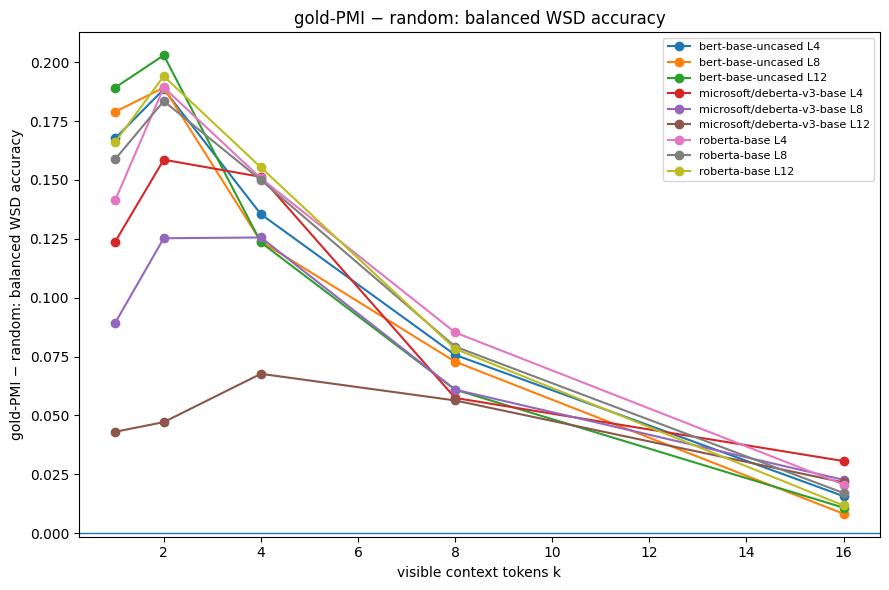

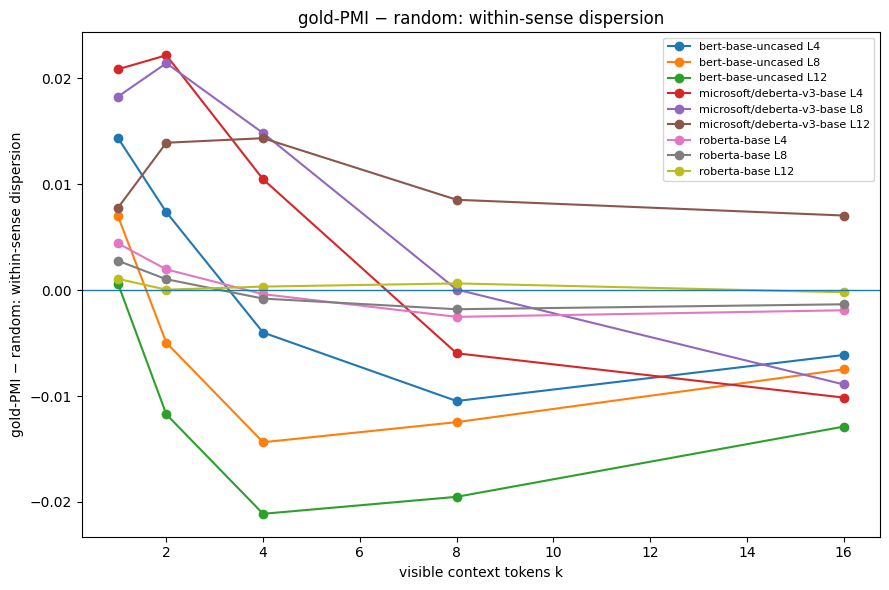

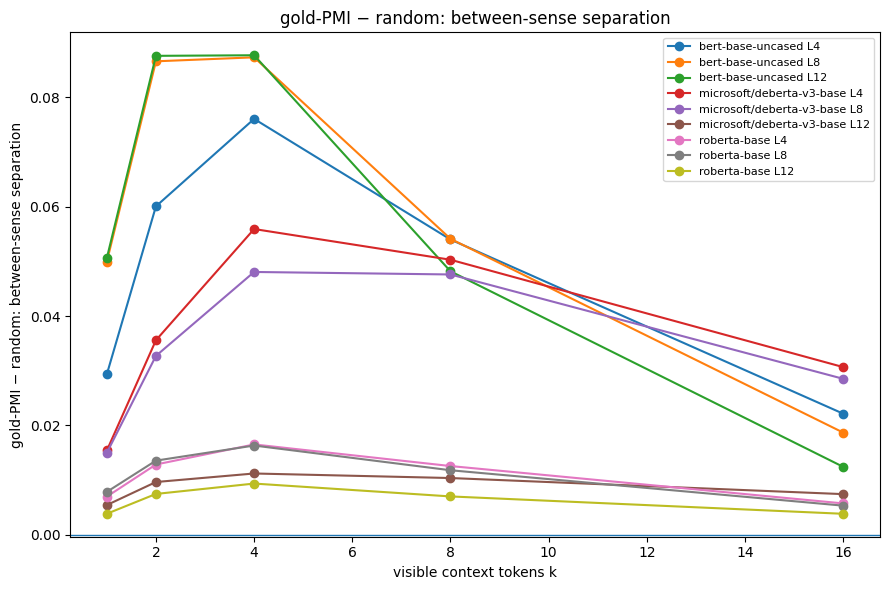

In [19]:
def get_effect_rows(metric, protocol="mask"):
    return effects[
        (effects["metric"] == metric)
        & (effects["protocol"] == protocol)
    ].copy()


for metric, ylabel, filename in [
    (
        "delta_balanced_accuracy",
        "gold-PMI − random: balanced WSD accuracy",
        "delta_accuracy_cross_model.png",
    ),
    (
        "delta_within_dispersion",
        "gold-PMI − random: within-sense dispersion",
        "delta_within_cross_model.png",
    ),
    (
        "delta_between_separation",
        "gold-PMI − random: between-sense separation",
        "delta_between_cross_model.png",
    ),
]:
    e = get_effect_rows(metric)

    plt.figure(figsize=(9, 6))

    for (model, layer), g in e.groupby(["model", "layer"]):
        g = g.sort_values("reveal_k")

        plt.plot(
            g["reveal_k"],
            g["mean_delta"],
            marker="o",
            label=f"{model} L{layer}",
        )

    plt.axhline(0, linewidth=1)
    plt.xlabel("visible context tokens k")
    plt.ylabel(ylabel)
    plt.title(ylabel)
    plt.legend(fontsize=8)
    plt.tight_layout()

    plt.savefig(
        PLOT_DIR / filename,
        bbox_inches="tight",
    )
    plt.show()

## 16. Separation-first diagnostic

For each condition compute:

\[
Q_k
=

rac{|\Delta B_k|}
{|\Delta W_k|+\epsilon}.
\]

Large \(Q_k\) means the matched informative-context effect is dominated by sense separation rather than within-sense contraction/expansion.

This ratio is descriptive; do not use it when both numerator and denominator are tiny.

In [20]:
separation_first = (
    paired
    .groupby([
        "model",
        "layer",
        "protocol",
        "reveal_k",
    ])[[
        "delta_balanced_accuracy",
        "delta_within_dispersion",
        "delta_between_separation",
    ]]
    .mean()
    .reset_index()
)

separation_first["separation_to_within_ratio"] = (
    np.abs(separation_first["delta_between_separation"])
    /
    (
        np.abs(separation_first["delta_within_dispersion"])
        + 1e-6
    )
)

separation_first.to_csv(
    RESULT_DIR / "separation_first_summary.csv",
    index=False,
)

display(separation_first)

,model,layer,protocol,reveal_k,delta_balanced_accuracy,delta_within_dispersion,delta_between_separation,separation_to_within_ratio
0,bert-base-uncased,4,mask,1,0.167688,0.014377,0.029338,2.040565
1,bert-base-uncased,4,mask,2,0.188531,0.007369,0.060070,8.150166
2,bert-base-uncased,4,mask,4,0.135482,-0.003999,0.076071,19.017258
3,bert-base-uncased,4,mask,8,0.075723,-0.010467,0.054001,5.158901
4,bert-base-uncased,4,mask,16,0.015730,-0.006118,0.022124,3.615727
5,bert-base-uncased,8,mask,1,0.178954,0.006996,0.049951,7.138859
6,bert-base-uncased,8,mask,2,0.189231,-0.004961,0.086609,17.453446
7,bert-base-uncased,8,mask,4,0.123915,-0.014357,0.087339,6.082917
8,bert-base-uncased,8,mask,8,0.072851,-0.012461,0.054127,4.343464
9,bert-base-uncased,8,mask,16,0.008245,-0.007477,0.018664,2.495789


## 17. Per-word mechanism profiles

Mechanisms are classified only when informative context improves stage-matched WSD accuracy.

This is descriptive; raw deltas are saved alongside the label.

In [21]:
TOL = 0.01

mechanism_rows = []

for _, row in paired.iterrows():
    dA = row["delta_balanced_accuracy"]
    dW = row["delta_within_dispersion"]
    dB = row["delta_between_separation"]

    if dA <= 0:
        mechanism = "no verified disambiguation gain"
    elif dW < -TOL and dB > TOL:
        mechanism = "contraction + separation"
    elif abs(dW) <= TOL and dB > TOL:
        mechanism = "separation"
    elif dW > TOL and dB > TOL:
        mechanism = "enrichment + separation"
    elif dW < -TOL:
        mechanism = "contraction"
    elif dW > TOL:
        mechanism = "enrichment"
    else:
        mechanism = "mixed"

    rec = row.to_dict()
    rec["mechanism"] = mechanism
    mechanism_rows.append(rec)

mechanisms = pd.DataFrame(mechanism_rows)

mechanisms.to_csv(
    RESULT_DIR / "per_word_mechanism_profiles.csv",
    index=False,
)

display(
    mechanisms[
        (mechanisms["layer"] == MAIN_LAYER)
        & (mechanisms["protocol"] == "mask")
    ][[
        "word",
        "model",
        "reveal_k",
        "delta_balanced_accuracy",
        "delta_within_dispersion",
        "delta_between_separation",
        "mechanism",
    ]]
    .sort_values(["model", "reveal_k", "word"])
    .head(100)
)

,word,model,reveal_k,delta_balanced_accuracy,delta_within_dispersion,delta_between_separation,mechanism
2,apple,bert-base-uncased,1,0.225000,-0.001309,0.091100,separation
47,arm,bert-base-uncased,1,0.146512,-0.019000,0.032414,contraction + separation
92,bank,bert-base-uncased,1,0.140909,0.062042,0.058818,enrichment + separation
137,bass,bert-base-uncased,1,0.101667,-0.002974,0.017639,separation
182,bow,bert-base-uncased,1,0.307692,0.004242,0.094554,separation
...,...,...,...,...,...,...,...
5,apple,microsoft/deberta-v3-base,1,0.073750,-0.004007,0.012076,separation
50,arm,microsoft/deberta-v3-base,1,0.074419,0.003242,0.013767,separation
95,bank,microsoft/deberta-v3-base,1,0.150000,0.011240,0.012099,enrichment + separation
140,bass,microsoft/deberta-v3-base,1,0.035833,-0.011147,0.003201,contraction


## 18. Evidence dose-response

The intervention itself has a continuous strength: mean gold-sense PMI of the visible tokens.

Across strategies/words/levels, test whether more diagnostic evidence correlates with:

- better WSD accuracy;
- greater between-sense separation;
- lower/higher within-sense dispersion.

This is exploratory because PMI is also used to construct `gold_pmi`.

In [22]:
dose_source = main_metrics[
    (main_metrics["layer"] == MAIN_LAYER)
    & (main_metrics["protocol"] == "mask")
].copy()

dose_rows = []

for model, g in dose_source.groupby("model"):
    for metric in [
        "balanced_accuracy",
        "between_separation",
        "within_dispersion",
        "separation_ratio",
    ]:
        clean = g[
            np.isfinite(g["mean_gold_pmi_visible"])
            & np.isfinite(g[metric])
        ]

        rho, p = spearmanr(
            clean["mean_gold_pmi_visible"],
            clean[metric],
        )

        dose_rows.append({
            "model": model,
            "metric": metric,
            "spearman_rho": float(rho),
            "p_value": float(p),
            "n_conditions": len(clean),
        })

dose_response = pd.DataFrame(dose_rows)

dose_response.to_csv(
    RESULT_DIR / "evidence_dose_response.csv",
    index=False,
)

display(dose_response)

,model,metric,spearman_rho,p_value,n_conditions
0,bert-base-uncased,balanced_accuracy,0.099654,1.731715e-02,570
1,bert-base-uncased,between_separation,0.216341,1.831968e-07,570
2,bert-base-uncased,within_dispersion,-0.166503,6.486112e-05,570
3,bert-base-uncased,separation_ratio,0.281088,8.234116e-12,570
4,microsoft/deberta-v3-base,balanced_accuracy,-0.113845,6.510557e-03,570
5,microsoft/deberta-v3-base,between_separation,0.235850,1.204533e-08,570
6,microsoft/deberta-v3-base,within_dispersion,-0.014163,7.358018e-01,570
7,microsoft/deberta-v3-base,separation_ratio,0.284367,4.593771e-12,570
8,roberta-base,balanced_accuracy,0.004986,9.054514e-01,570
9,roberta-base,between_separation,0.170503,4.280845e-05,570


## 19. Strategy ablation: gold-PMI vs local vs random vs anti-PMI

,strategy,reveal_k,balanced_accuracy,within_dispersion,between_separation,separation_ratio,mean_gold_pmi_visible
0,anti_pmi,1,0.600841,0.240481,0.035236,0.151553,-0.187197
1,anti_pmi,2,0.670181,0.266809,0.062320,0.243201,-0.219924
2,anti_pmi,4,0.765816,0.297001,0.103993,0.359884,-0.234927
3,anti_pmi,8,0.856249,0.328526,0.166427,0.535593,-0.187248
4,anti_pmi,16,0.896626,0.367028,0.244525,0.703913,0.005859
5,gold_pmi,1,0.768130,0.243910,0.083697,0.353543,1.106924
6,gold_pmi,2,0.871387,0.256656,0.145212,0.584929,1.027579
7,gold_pmi,4,0.916142,0.272684,0.207100,0.781713,0.874574
8,gold_pmi,8,0.944489,0.299214,0.253612,0.877241,0.646924
9,gold_pmi,16,0.944408,0.337872,0.297190,0.910203,0.417340


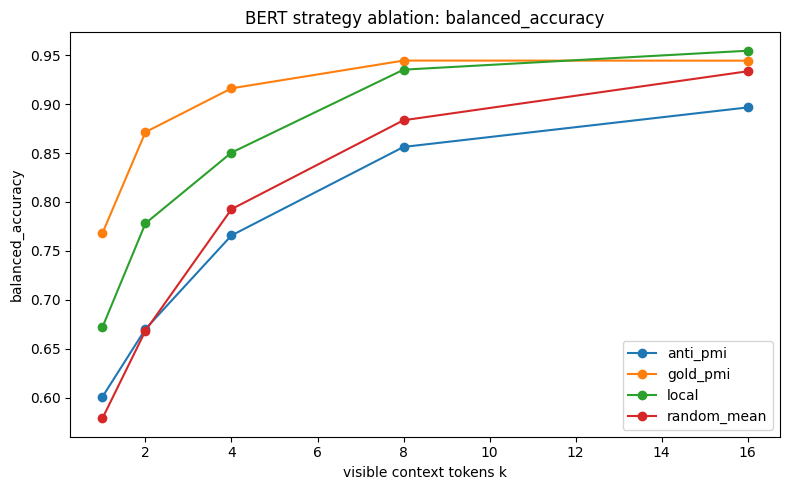

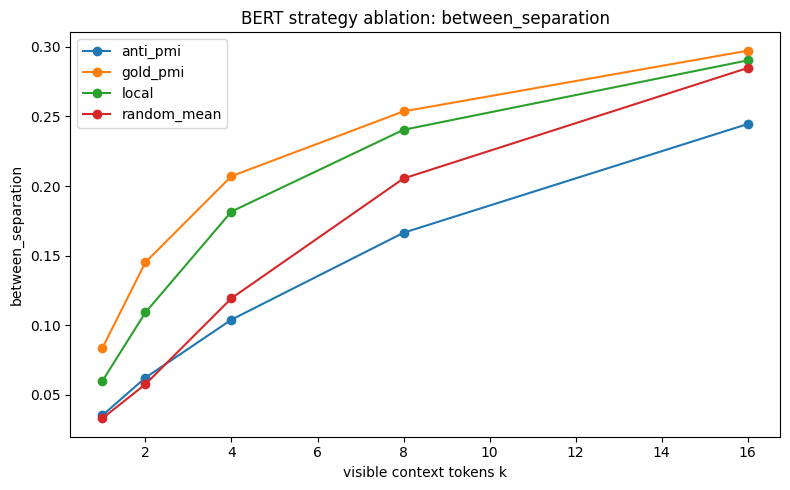

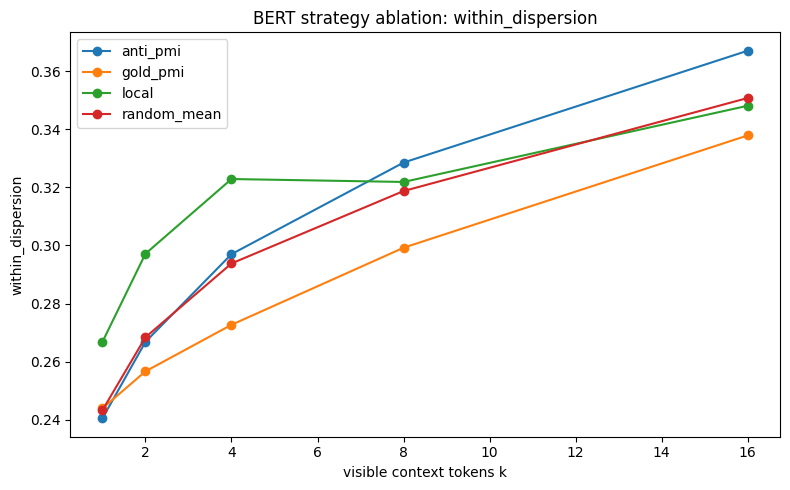

In [23]:
strategy_summary = pd.DataFrame()

if len(strategy_metrics):
    strategy_collapsed = collapse_random_seeds(strategy_metrics)

    strategy_summary = (
        strategy_collapsed[
            strategy_collapsed["layer"] == MAIN_LAYER
        ]
        .groupby(["strategy", "reveal_k"])[[
            "balanced_accuracy",
            "within_dispersion",
            "between_separation",
            "separation_ratio",
            "mean_gold_pmi_visible",
        ]]
        .mean()
        .reset_index()
    )

    strategy_summary.to_csv(
        RESULT_DIR / "bert_strategy_ablation_summary.csv",
        index=False,
    )

    display(strategy_summary)

    for metric in [
        "balanced_accuracy",
        "between_separation",
        "within_dispersion",
    ]:
        plt.figure(figsize=(8, 5))

        for strategy, g in strategy_summary.groupby("strategy"):
            plt.plot(
                g["reveal_k"],
                g[metric],
                marker="o",
                label=strategy,
            )

        plt.xlabel("visible context tokens k")
        plt.ylabel(metric)
        plt.title(f"BERT strategy ablation: {metric}")
        plt.legend()
        plt.tight_layout()

        plt.savefig(
            PLOT_DIR / f"strategy_ablation_{metric}.png",
            bbox_inches="tight",
        )
        plt.show()

## 20. Mask-vs-delete artifact ablation

In [24]:
protocol_comparison = pd.DataFrame()

if len(delete_metrics):
    delete_collapsed = collapse_random_seeds(delete_metrics)
    delete_paired = paired_gold_vs_random(delete_collapsed)

    bert_mask = paired[
        (paired["model"] == "bert-base-uncased")
        & (paired["protocol"] == "mask")
    ].copy()

    bert_delete = delete_paired[
        delete_paired["protocol"] == "delete"
    ].copy()

    cols = [
        "word",
        "layer",
        "reveal_k",
        "delta_balanced_accuracy",
        "delta_within_dispersion",
        "delta_between_separation",
    ]

    m = bert_mask[cols].rename(columns={
        "delta_balanced_accuracy": "mask_delta_accuracy",
        "delta_within_dispersion": "mask_delta_within",
        "delta_between_separation": "mask_delta_between",
    })

    d = bert_delete[cols].rename(columns={
        "delta_balanced_accuracy": "delete_delta_accuracy",
        "delta_within_dispersion": "delete_delta_within",
        "delta_between_separation": "delete_delta_between",
    })

    protocol_comparison = m.merge(
        d,
        on=["word", "layer", "reveal_k"],
        how="inner",
    )

    protocol_comparison.to_csv(
        RESULT_DIR / "mask_vs_delete_paired_effects.csv",
        index=False,
    )

    display(
        protocol_comparison
        .groupby(["layer", "reveal_k"])[[
            "mask_delta_accuracy",
            "delete_delta_accuracy",
            "mask_delta_within",
            "delete_delta_within",
            "mask_delta_between",
            "delete_delta_between",
        ]]
        .mean()
        .reset_index()
    )

,layer,reveal_k,mask_delta_accuracy,delete_delta_accuracy,mask_delta_within,delete_delta_within,mask_delta_between,delete_delta_between
0,4,1,0.167688,0.202347,0.014377,0.005310,0.029338,0.033407
1,4,2,0.188531,0.194769,0.007369,-0.000784,0.060070,0.063601
2,4,4,0.135482,0.142099,-0.003999,-0.010225,0.076071,0.071933
3,4,8,0.075723,0.076089,-0.010467,-0.010887,0.054001,0.048408
4,4,16,0.015730,0.021452,-0.006118,-0.009558,0.022124,0.021292
5,8,1,0.178954,0.187717,0.006996,-0.001933,0.049951,0.045875
6,8,2,0.189231,0.200195,-0.004961,-0.008382,0.086609,0.078283
7,8,4,0.123915,0.147885,-0.014357,-0.018823,0.087339,0.077105
8,8,8,0.072851,0.066001,-0.012461,-0.017395,0.054127,0.047569
9,8,16,0.008245,0.018917,-0.007477,-0.017469,0.018664,0.018981


## 21. Bank visualization at matched \(k=2\)

A single PCA basis is fit to gold-PMI and one random seed together.

The plot is exploratory only.

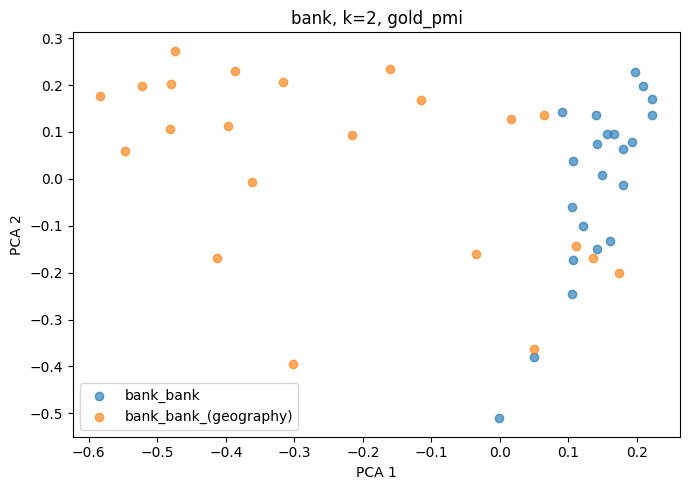

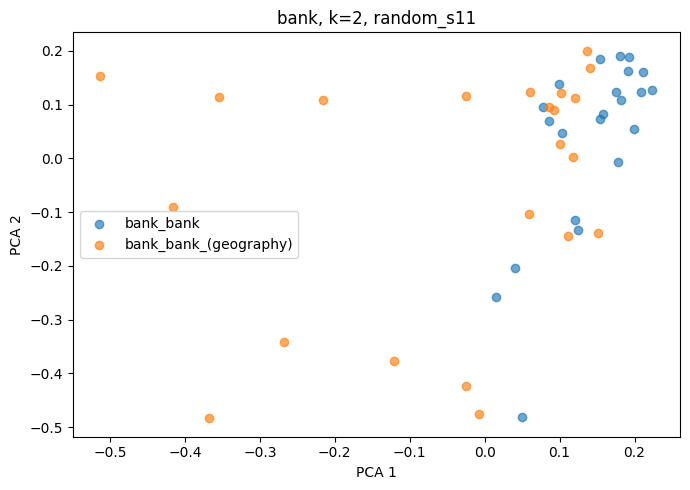

In [25]:
def load_cached_test_embedding(
    model_name,
    protocol,
    tag,
    layer,
):
    exp_dir = (
        CACHE_DIR
        / f"{safe_model_name(model_name)}__{protocol}__{tag}"
    )

    meta = pd.read_parquet(
        exp_dir / "test_variants.parquet"
    )

    emb = np.load(
        exp_dir / f"test_layer{layer}.npy",
        mmap_mode="r",
    )

    return meta, emb


if "bank" in VALID_WORDS:
    meta, emb = load_cached_test_embedding(
        "bert-base-uncased",
        "mask",
        "main",
        MAIN_LAYER,
    )

    use_strategies = [
        "gold_pmi",
        f"random_s{RANDOM_SEEDS[0]}",
    ]

    mask = (
        (meta["word"] == "bank")
        & (meta["reveal_k"] == 2)
        & (meta["strategy"].isin(use_strategies))
    )

    idx = np.where(mask.to_numpy())[0]
    x = np.asarray(emb[idx])
    m = meta.iloc[idx].copy().reset_index(drop=True)

    xy = PCA(
        n_components=2,
        random_state=SEED,
    ).fit_transform(x)

    m["pc1"] = xy[:, 0]
    m["pc2"] = xy[:, 1]

    for strategy in use_strategies:
        g = m[m["strategy"] == strategy]

        plt.figure(figsize=(7, 5))

        for sense, gs in g.groupby("sense_name"):
            plt.scatter(
                gs["pc1"],
                gs["pc2"],
                alpha=0.65,
                label=sense,
            )

        plt.xlabel("PCA 1")
        plt.ylabel("PCA 2")
        plt.title(f"bank, k=2, {strategy}")
        plt.legend()
        plt.tight_layout()

        plt.savefig(
            PLOT_DIR / f"pca_bank_k2_{strategy}.png",
            bbox_inches="tight",
        )
        plt.show()

# Interpretation checklist

A robust **separation-first** result should satisfy most of the following:

1. At small \(k\), gold-PMI improves WSD balanced accuracy over the five-seed random mean.
2. At the same \(k\), \(\Delta B > 0\) across most words.
3. Early \(\Delta W\) is near zero or much smaller in magnitude than \(\Delta B\).
4. The pattern appears in BERT, RoBERTa, and DeBERTa.
5. It survives multiple layers.
6. It survives the delete-protocol ablation.
7. Gold-PMI is stronger than anti-PMI and usually stronger than local/random.
8. Random-seed variability is much smaller than the informative-context effect.
9. Later \(k\) may show relative contraction without implying absolute cloud contraction.

The claim should **not** be upgraded if it only appears in BERT layer 12 or disappears under deletion.

In [26]:
# Save sampling/config metadata.

train_sampling.to_csv(
    RESULT_DIR / "train_sampling.csv",
    index=False,
)

test_sampling.to_csv(
    RESULT_DIR / "test_sampling.csv",
    index=False,
)

raw_counts.to_csv(
    RESULT_DIR / "raw_dataset_counts.csv",
    index=False,
)

config = {
    "profile": PROFILE,
    "dataset": DATASET_ID,
    "eligible_words": VALID_WORDS,
    "models": MODELS,
    "layers": MAIN_LAYERS,
    "reveal_counts": REVEAL_COUNTS,
    "random_seeds": RANDOM_SEEDS,
    "max_train_per_sense": MAX_TRAIN_PER_SENSE,
    "max_test_per_sense": MAX_TEST_PER_SENSE,
    "min_train_per_sense": MIN_TRAIN_PER_SENSE,
    "min_test_per_sense": MIN_TEST_PER_SENSE,
    "run_delete_ablation": RUN_DELETE_ABLATION,
    "run_strategy_ablation": RUN_STRATEGY_ABLATION,
    "seed": SEED,
}

with open(RESULT_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)

print("RESULT FILES:")
for p in sorted(RESULT_DIR.iterdir()):
    print(" ", p.name)

print("\nPLOTS:")
for p in sorted(PLOT_DIR.iterdir()):
    print(" ", p.name)

RESULT FILES:
  bert_delete_protocol_metrics.csv
  bert_strategy_ablation_metrics.csv
  bert_strategy_ablation_summary.csv
  bootstrap_effects_over_words.csv
  config.json
  evidence_dose_response.csv
  main_cross_model_condition_metrics.csv
  main_cross_model_random_collapsed.csv
  mask_vs_delete_paired_effects.csv
  paired_gold_minus_random.csv
  per_word_mechanism_profiles.csv
  random_seed_stability.csv
  raw_dataset_counts.csv
  separation_first_summary.csv
  test_sampling.csv
  train_sampling.csv

PLOTS:
  delta_accuracy_cross_model.png
  delta_between_cross_model.png
  delta_within_cross_model.png
  pca_bank_k2_gold_pmi.png
  pca_bank_k2_random_s11.png
  strategy_ablation_balanced_accuracy.png
  strategy_ablation_between_separation.png
  strategy_ablation_within_dispersion.png


In [27]:
# Pack only results + plots for easy upload back to ChatGPT.
resource_export = ROOT / "resource_export"
resource_export.mkdir(exist_ok=True)

for src_dir in [RESULT_DIR, PLOT_DIR]:
    dst = resource_export / src_dir.name

    if dst.exists():
        shutil.rmtree(dst)

    shutil.copytree(src_dir, dst)

archive = shutil.make_archive(
    "semantic_disambiguation_geometry_v3_resource_results",
    "zip",
    root_dir=resource_export,
)

print("RESULT ARCHIVE:", archive)
print("Embedding caches remain under:", CACHE_DIR)

NameError: name 'shutil' is not defined

## Recommended next step after V3

Do **not** add more models just because compute is available.

If V3 is consistent, the highest-value next resource is an **external lexical dataset / human-graded replication**, not model #4 or random seed #20.

At that point the study has three levels:

1. **CoarseWSD-20 discovery/resource panel** — 20 lexical items.
2. **Cross-encoder replication** — BERT / RoBERTa / DeBERTa.
3. **External semantic validation** — e.g. RAW-C or another sense-labelled resource.

That is much stronger than simply making the current matrix wider.